# Concept Co-occurrence Graph Analysis

Analysis of concept co-occurrence graphs built from ICLR articles (2017–2025).

**Data sources**
- Pre-built cumulative graphs: `graph_2017_2022` (train), `graph_2017_2023` (val), `graph_2017_2024` (test)
- Test edges per split: `test_edges_train_2023`, `test_edges_val_2024`, `test_edges_test_2025`
- All-years cumulative graph: built from `normalized_concepts_all.csv` (2017–2025)

Sections:
1. Load pre-built graphs + construct cumulative all-years graph
2. Cross-split graph comparison
3. Degree distribution
4. Top concepts and edges
5. Edge weight distribution
6. Connected components
7. Clustering coefficient
8. Test edges analysis
9. Temporal evolution (new vs. recurring, cumulative growth)

## Setup

In [1]:
import ast
import pickle
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

DATA_ROOT   = Path('../data')
LP_DIR      = DATA_ROOT / 'link_prediction' / 'llm_concept_datasets'
ALL_CSV     = DATA_ROOT / 'extracted_concepts' / 'llm' / 'normalized_concepts.csv'
IMAGES_DIR  = Path('images/graph_analysis')
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = IMAGES_DIR / f'{name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')


## Load Pre-built Graphs

In [2]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Three cumulative NetworkX graphs
G_train = load_pkl(LP_DIR / 'graph_2017_2022.pkl')   # 2017–2022
G_val   = load_pkl(LP_DIR / 'graph_2017_2023.pkl')   # 2017–2023
G_test  = load_pkl(LP_DIR / 'graph_2017_2024.pkl')   # 2017–2024

# Test edges (new edges that appeared in the *next* year)
te_train = load_pkl(LP_DIR / 'test_edges_train_2023.pkl')  # 2023 new edges
te_val   = load_pkl(LP_DIR / 'test_edges_val_2024.pkl')    # 2024 new edges
te_test  = load_pkl(LP_DIR / 'test_edges_test_2025.pkl')   # 2025 new edges

SPLITS = {
    'Train (2017–2022)': G_train,
    'Val   (2017–2023)': G_val,
    'Test  (2017–2024)': G_test,
}

for name, G in SPLITS.items():
    print(f'{name}: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')


Train (2017–2022): 24,742 nodes, 162,637 edges
Val   (2017–2023): 34,155 nodes, 229,822 edges
Test  (2017–2024): 47,461 nodes, 326,402 edges


## Build All-Years Cumulative Graph (2017–2025)

Constructed from `normalized_concepts.csv` using the `normalized_concepts` column.

In [3]:
def parse_concepts(val):
    if isinstance(val, list):
        return [str(x).strip() for x in val if str(x).strip()]
    if not isinstance(val, str) or not val.strip():
        return []
    val = val.strip()
    if val.startswith('['):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
        except (ValueError, SyntaxError):
            pass
    return [x.strip().strip("'\"") for x in val.split(',') if x.strip()]


def build_cumulative_graph(df):
    """Build a single NetworkX graph from a concepts dataframe."""
    G = nx.Graph()
    for _, row in df.iterrows():
        concepts = parse_concepts(row['normalized_concepts'])
        unique = list(set(concepts))
        yr = int(row['year']) if 'year' in row else 0
        for c in unique:
            if G.has_node(c):
                G.nodes[c]['freq'] += 1
            else:
                G.add_node(c, freq=1)
        for a, b in combinations(sorted(unique), 2):
            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)
    return G


def build_yearly_graphs(df):
    """Build per-year snapshot dicts for temporal analysis."""
    graphs = {}
    for yr, grp in df.groupby('year'):
        freq = Counter()
        edges = Counter()
        for _, row in grp.iterrows():
            concepts = parse_concepts(row['normalized_concepts'])
            unique = list(set(concepts))
            for c in unique:
                freq[c] += 1
            for a, b in combinations(sorted(unique), 2):
                p = (a, b) if a <= b else (b, a)
                edges[p] += 1
        graphs[int(yr)] = {'n_docs': len(grp), 'concept_freq': freq, 'edges': edges}
    return graphs


df_all = pd.read_csv(ALL_CSV)
print(f'Loaded {len(df_all):,} articles, years {df_all["year"].min()}–{df_all["year"].max()}')

print('Building all-years cumulative graph...')
G_all = build_cumulative_graph(df_all)
print(f'G_all: {G_all.number_of_nodes():,} nodes, {G_all.number_of_edges():,} edges')

print('Building per-year snapshots...')
yearly_graphs = build_yearly_graphs(df_all)
years = sorted(yearly_graphs.keys())
print(f'Years: {years}')


Loaded 11,349 articles, years 2017–2025
Building all-years cumulative graph...
G_all: 69,273 nodes, 484,790 edges
Building per-year snapshots...
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## Cross-Split Graph Comparison

In [4]:
def graph_summary(G, label):
    degs = [d for _, d in G.degree()]
    weights = [w for _, _, w in G.edges(data='weight', default=1)]
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    return {
        'Split': label,
        'Nodes': G.number_of_nodes(),
        'Edges': G.number_of_edges(),
        'Density': round(nx.density(G), 6),
        'Mean degree': round(np.mean(degs), 2),
        'Max degree': max(degs),
        'Components': len(comps),
        'LCC size': len(comps[0]),
        'LCC %': round(100 * len(comps[0]) / G.number_of_nodes(), 1),
        'Avg weight': round(np.mean(weights), 3),
        'Max weight': max(weights),
    }


summary_rows = [
    graph_summary(G_train, 'Train 2017–2022'),
    graph_summary(G_val,   'Val   2017–2023'),
    graph_summary(G_test,  'Test  2017–2024'),
    graph_summary(G_all,   'All   2017–2025'),
]
summary_df = pd.DataFrame(summary_rows).set_index('Split')
display(summary_df)


,Nodes,Edges,Density,Mean degree,Max degree,Components,LCC size,LCC %,Avg weight,Max weight
Split,,,,,,,,,,
Train 2017–2022,24742,162637,0.000531,13.15,1825,79,23977,96.9,1.027,31
Val 2017–2023,34155,229822,0.000394,13.46,2127,109,33087,96.9,1.028,40
Test 2017–2024,47461,326402,0.000290,13.75,2444,141,46063,97.1,1.029,44
All 2017–2025,69273,484790,0.000202,14.00,5540,189,67422,97.3,1.031,52


Saved: images/graph_analysis/01_split_comparison.png


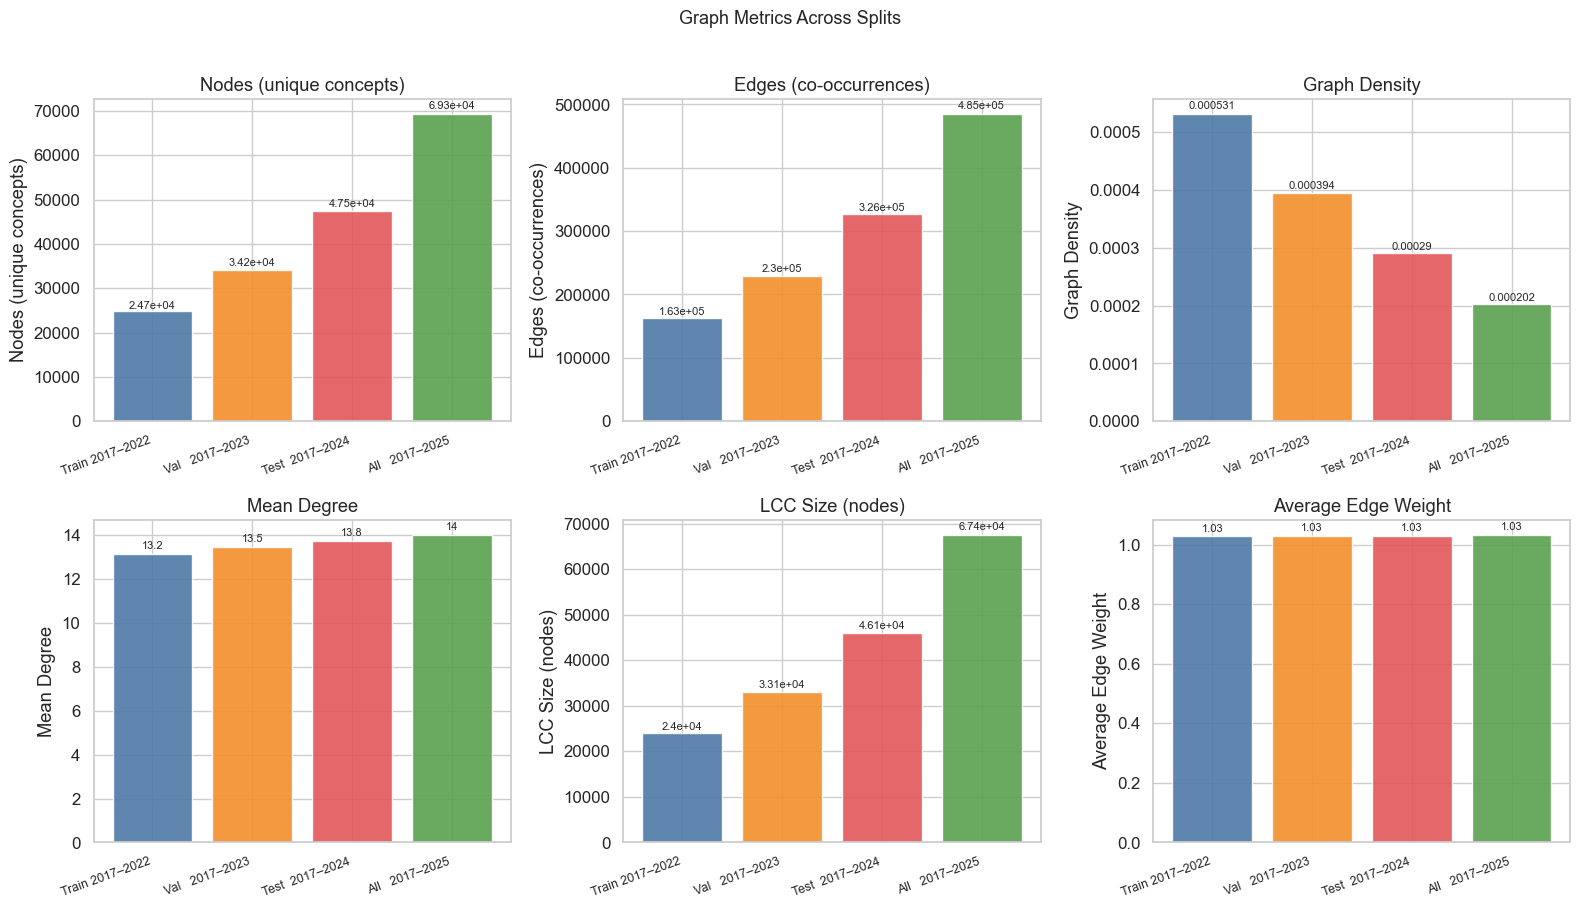

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

metrics = [
    ('Nodes',       'Nodes (unique concepts)'),
    ('Edges',       'Edges (co-occurrences)'),
    ('Density',     'Graph Density'),
    ('Mean degree', 'Mean Degree'),
    ('LCC size',    'LCC Size (nodes)'),
    ('Avg weight',  'Average Edge Weight'),
]
colors = ['#4e79a7', '#f28e2b', '#e15759', '#59a14f']
labels = summary_df.index.tolist()

for ax, (col, ylabel) in zip(axes, metrics):
    vals = summary_df[col].values
    ax.bar(labels, vals, color=colors, edgecolor='white', alpha=0.9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    for i, v in enumerate(vals):
        ax.text(i, v * 1.01, f'{v:,.3g}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Graph Metrics Across Splits', fontsize=13, y=1.01)
plt.tight_layout()
savefig('01_split_comparison')
plt.show()


## Degree Distribution

Saved: images/graph_analysis/02_degree_distribution.png


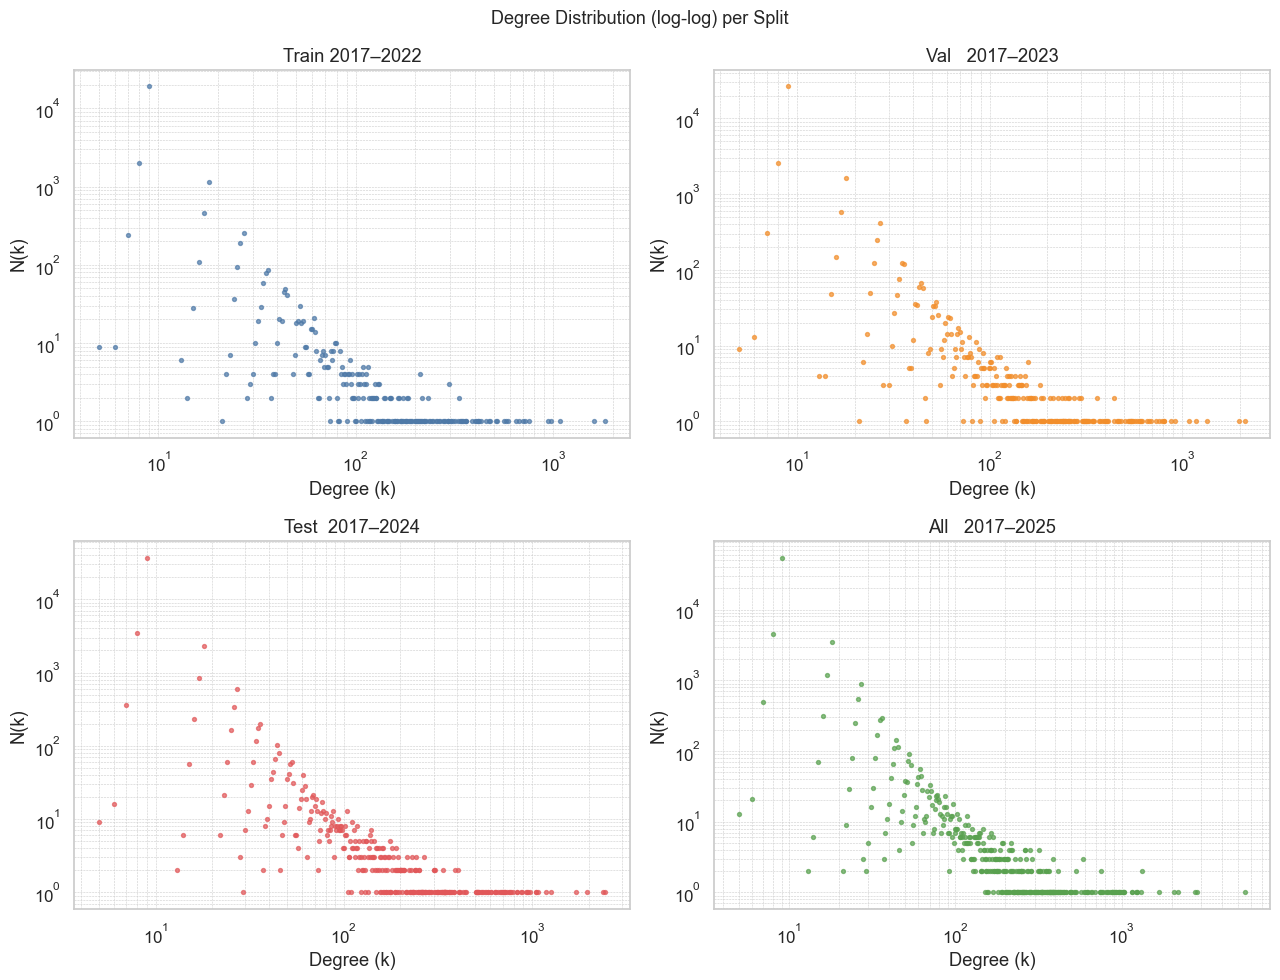

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

graph_items = [
    ('Train 2017–2022', G_train, '#4e79a7'),
    ('Val   2017–2023', G_val,   '#f28e2b'),
    ('Test  2017–2024', G_test,  '#e15759'),
    ('All   2017–2025', G_all,   '#59a14f'),
]

for ax, (label, G, color) in zip(axes, graph_items):
    degrees = sorted([d for _, d in G.degree()])
    deg_counts = Counter(degrees)
    ks = sorted(deg_counts)
    ns = [deg_counts[k] for k in ks]
    ax.scatter(ks, ns, s=8, alpha=0.7, color=color)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (k)')
    ax.set_ylabel('N(k)')
    ax.set_title(label)
    ax.grid(True, which='both', ls='--', lw=0.4)

plt.suptitle('Degree Distribution (log-log) per Split', fontsize=13)
plt.tight_layout()
savefig('02_degree_distribution')
plt.show()


## Top Concepts by Degree and Frequency (All-Years Graph)

Saved: images/graph_analysis/03_top_concepts.png


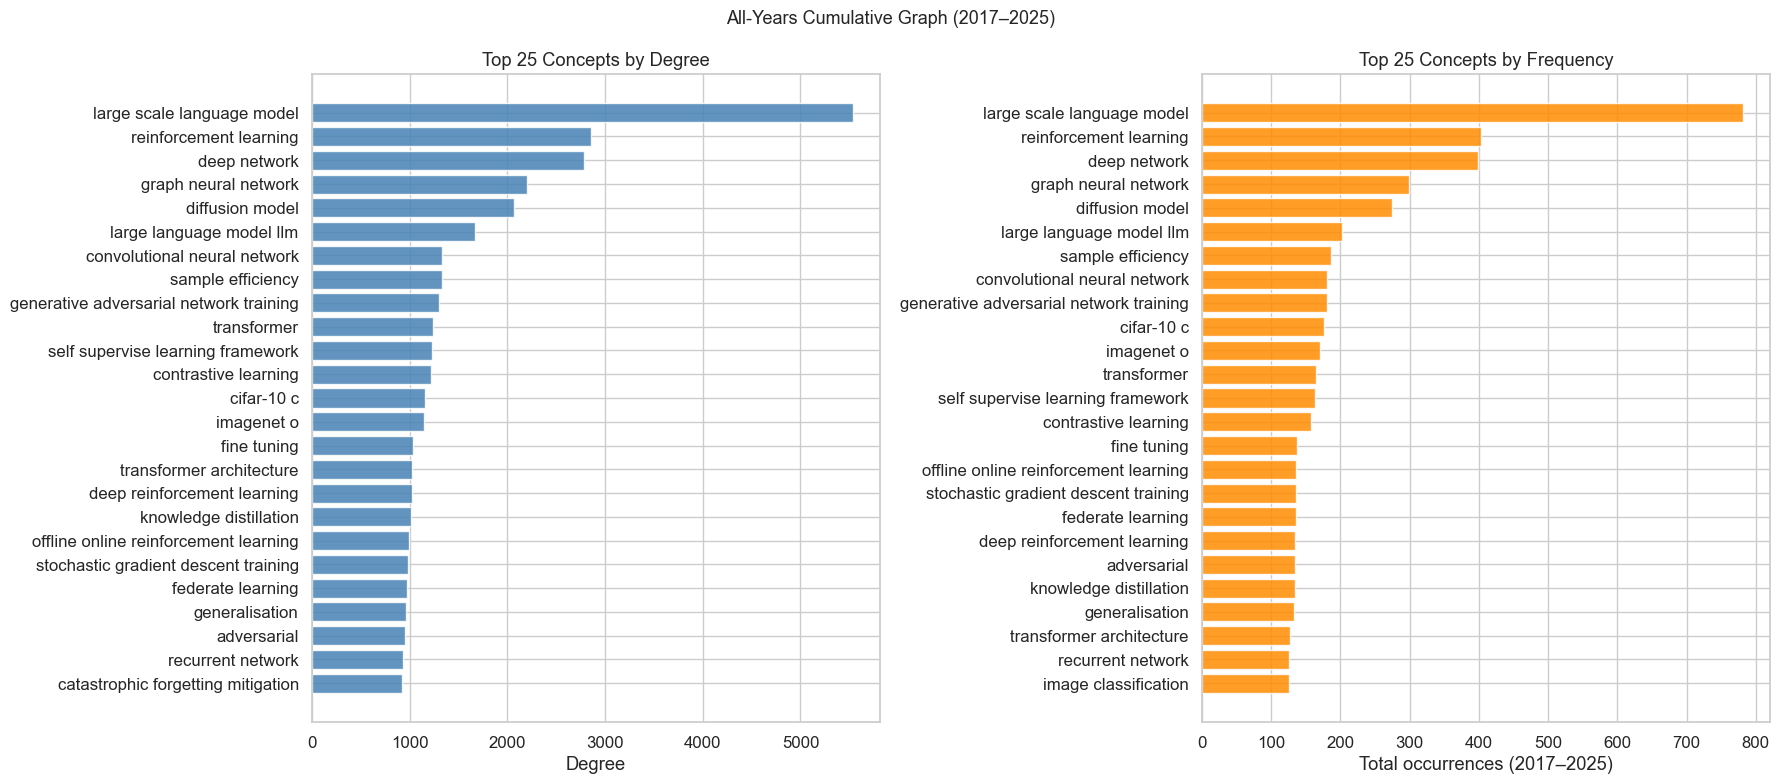

In [7]:
top_n = 25

top_degree = sorted(G_all.degree(), key=lambda x: x[1], reverse=True)[:top_n]

freq_counter = Counter()
for yr_data in yearly_graphs.values():
    for c, f in yr_data['concept_freq'].items():
        freq_counter[c] += f
top_freq = freq_counter.most_common(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

names_d, vals_d = zip(*top_degree)
axes[0].barh(list(names_d)[::-1], list(vals_d)[::-1], color='steelblue', alpha=0.85)
axes[0].set_xlabel('Degree')
axes[0].set_title(f'Top {top_n} Concepts by Degree')

names_f, vals_f = zip(*top_freq)
axes[1].barh(list(names_f)[::-1], list(vals_f)[::-1], color='darkorange', alpha=0.85)
axes[1].set_xlabel('Total occurrences (2017–2025)')
axes[1].set_title(f'Top {top_n} Concepts by Frequency')

plt.suptitle('All-Years Cumulative Graph (2017–2025)', fontsize=13)
plt.tight_layout()
savefig('03_top_concepts')
plt.show()


## Top Co-occurrence Pairs (All-Years Graph)

Saved: images/graph_analysis/04_top_edges.png


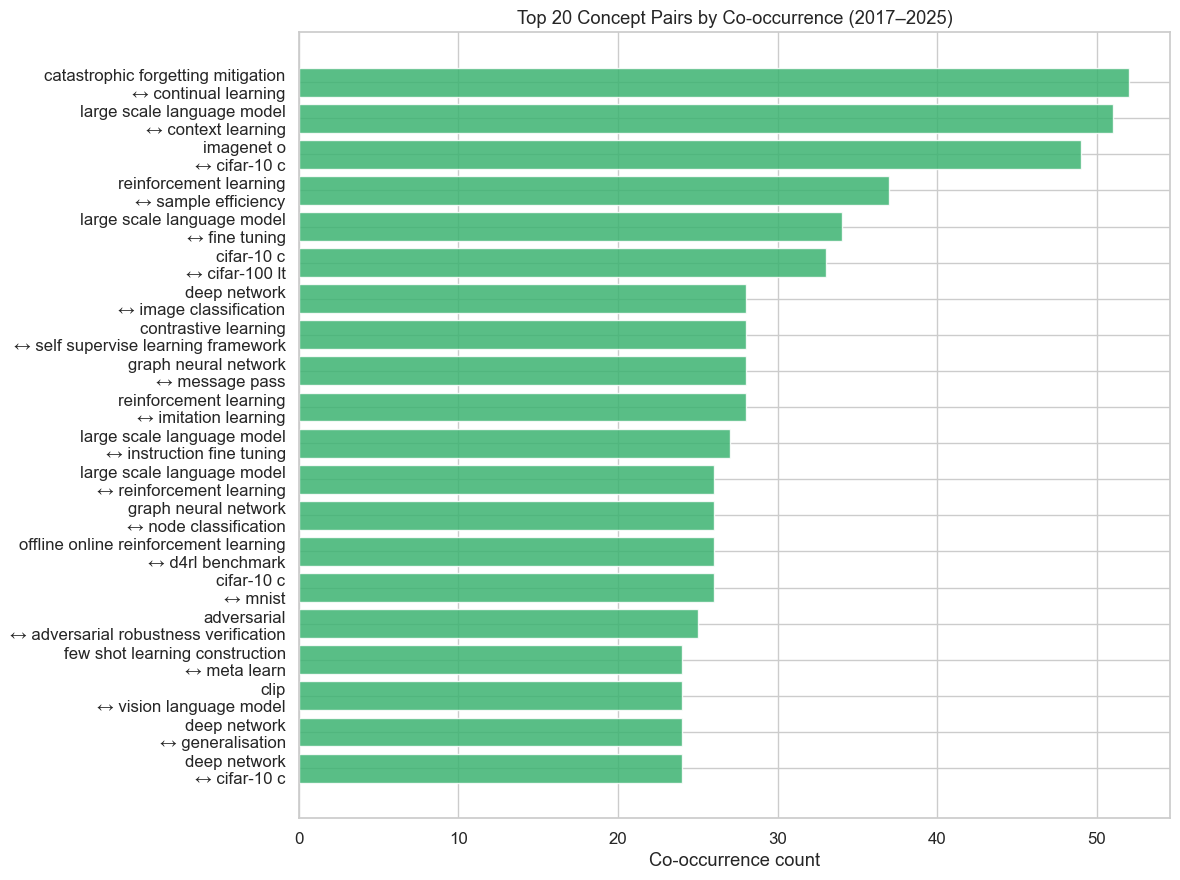

,concept_a,concept_b,co_occurrences
0,catastrophic forgetting mitigation,continual learning,52
1,large scale language model,context learning,51
2,imagenet o,cifar-10 c,49
3,reinforcement learning,sample efficiency,37
4,large scale language model,fine tuning,34
5,cifar-10 c,cifar-100 lt,33
6,deep network,image classification,28
7,contrastive learning,self supervise learning framework,28
8,graph neural network,message pass,28
9,reinforcement learning,imitation learning,28


In [8]:
edges_sorted = sorted(G_all.edges(data='weight'), key=lambda x: x[2], reverse=True)
top_edges = pd.DataFrame(
    [(u, v, w) for u, v, w in edges_sorted[:30]],
    columns=['concept_a', 'concept_b', 'co_occurrences'],
)

fig, ax = plt.subplots(figsize=(12, 9))
labels = [f"{r.concept_a}\n↔ {r.concept_b}" for _, r in top_edges.head(20).iterrows()]
ax.barh(labels[::-1], top_edges['co_occurrences'].head(20).values[::-1],
        color='mediumseagreen', alpha=0.85)
ax.set_xlabel('Co-occurrence count')
ax.set_title('Top 20 Concept Pairs by Co-occurrence (2017–2025)')
plt.tight_layout()
savefig('04_top_edges')
plt.show()

top_edges.head(20)


## Edge Weight Distribution

Saved: images/graph_analysis/05_edge_weight_distribution.png


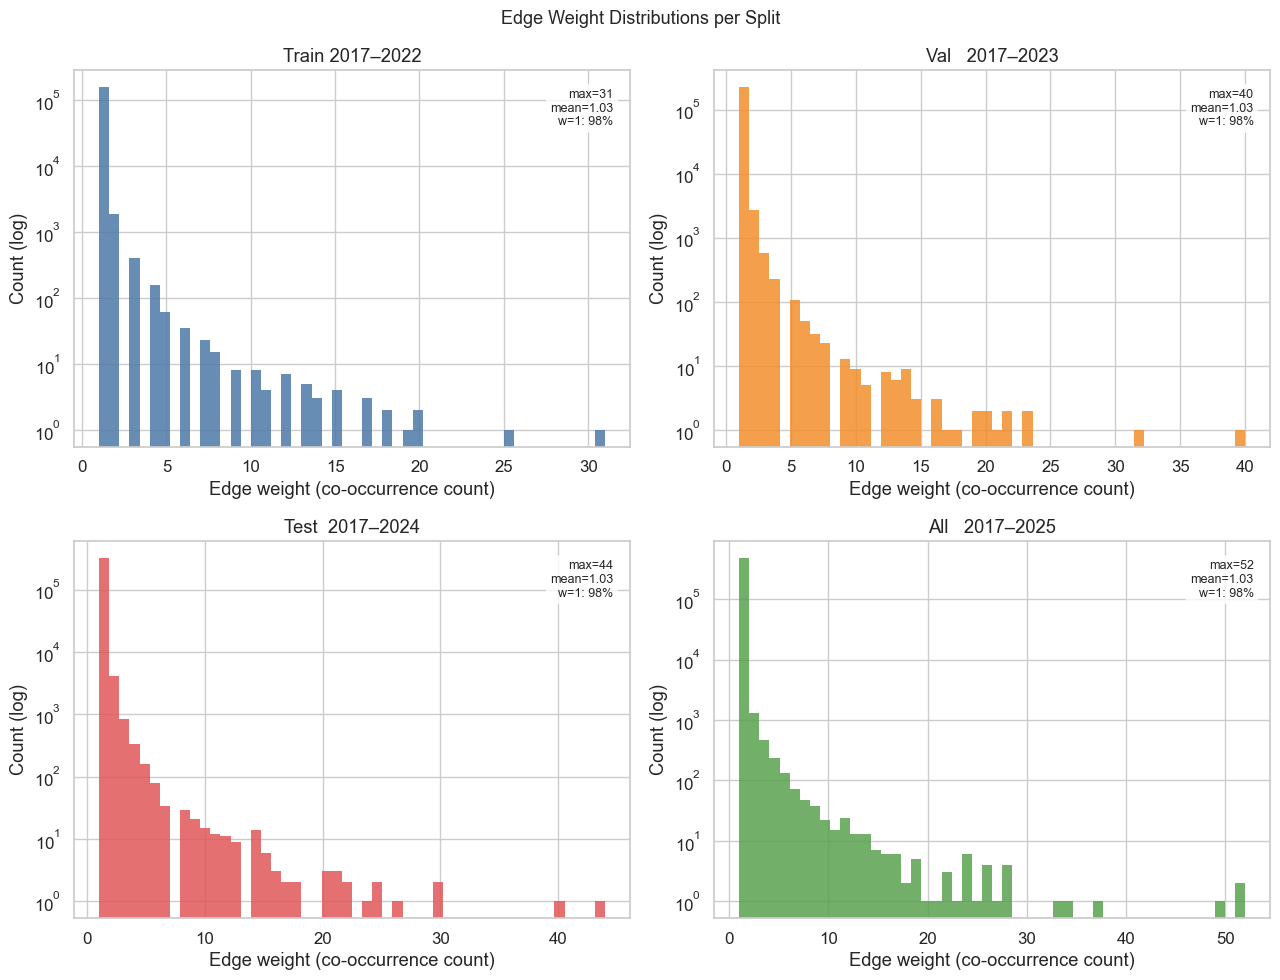

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (label, G, color) in zip(axes, graph_items):
    weights = np.array([w for _, _, w in G.edges(data='weight', default=1)])
    ax.hist(weights, bins=50, color=color, edgecolor='none', alpha=0.85)
    ax.set_yscale('log')
    ax.set_xlabel('Edge weight (co-occurrence count)')
    ax.set_ylabel('Count (log)')
    ax.set_title(label)
    ax.text(0.97, 0.95,
            f'max={weights.max()}\nmean={weights.mean():.2f}\nw=1: {(weights==1).mean()*100:.0f}%',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Edge Weight Distributions per Split', fontsize=13)
plt.tight_layout()
savefig('05_edge_weight_distribution')
plt.show()


## Connected Components

Saved: images/graph_analysis/06_connected_components.png


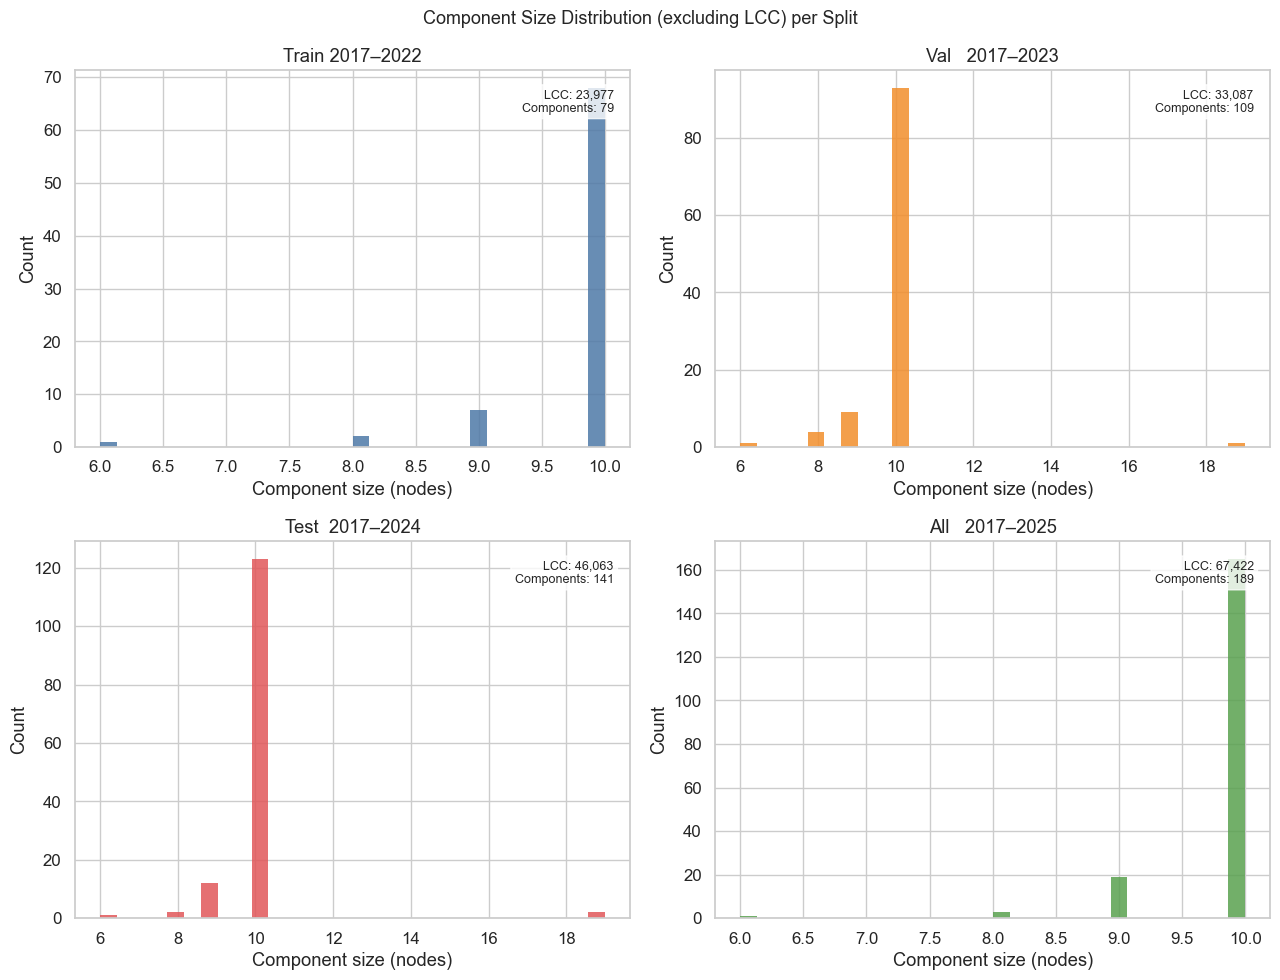

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (label, G, color) in zip(axes, graph_items):
    comp_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
    lcc = comp_sizes[0]
    ax.hist(comp_sizes[1:], bins=30, color=color, edgecolor='none', alpha=0.85)
    ax.set_xlabel('Component size (nodes)')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.text(0.97, 0.95,
            f'LCC: {lcc:,}\nComponents: {len(comp_sizes)}',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Component Size Distribution (excluding LCC) per Split', fontsize=13)
plt.tight_layout()
savefig('06_connected_components')
plt.show()


## Clustering Coefficient

Computing average clustering coefficients...
  Train 2017–2022: 0.9130
  Val   2017–2023: 0.9106
  Test  2017–2024: 0.9090
  All   2017–2025: 0.9081

Per-year clustering coefficient:
Saved: images/graph_analysis/07_clustering_coefficient.png


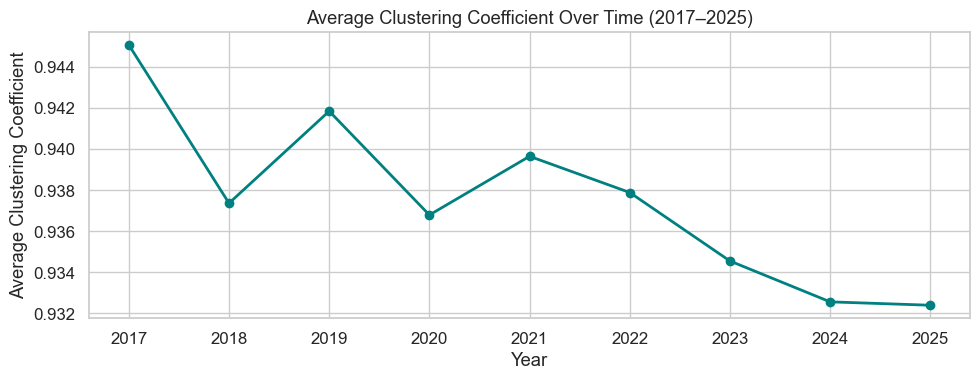

In [11]:
print('Computing average clustering coefficients...')
for label, G, _ in graph_items:
    cc = nx.average_clustering(G)
    print(f'  {label}: {cc:.4f}')

print('\nPer-year clustering coefficient:')
nx_yearly = {yr: None for yr in years}
for yr in years:
    g = yearly_graphs[yr]
    G = nx.Graph()
    for c, f in g['concept_freq'].items():
        G.add_node(c, freq=f)
    for (u, v), w in g['edges'].items():
        G.add_edge(u, v, weight=w)
    nx_yearly[yr] = G

clust_per_year = {yr: nx.average_clustering(nx_yearly[yr]) for yr in years}

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(clust_per_year.keys()), list(clust_per_year.values()),
        marker='o', linewidth=2, color='teal')
ax.set_xlabel('Year')
ax.set_ylabel('Average Clustering Coefficient')
ax.set_title('Average Clustering Coefficient Over Time (2017–2025)')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
savefig('07_clustering_coefficient')
plt.show()


## Per-Year Graph Statistics

Saved: images/graph_analysis/09_yearly_statistics.png


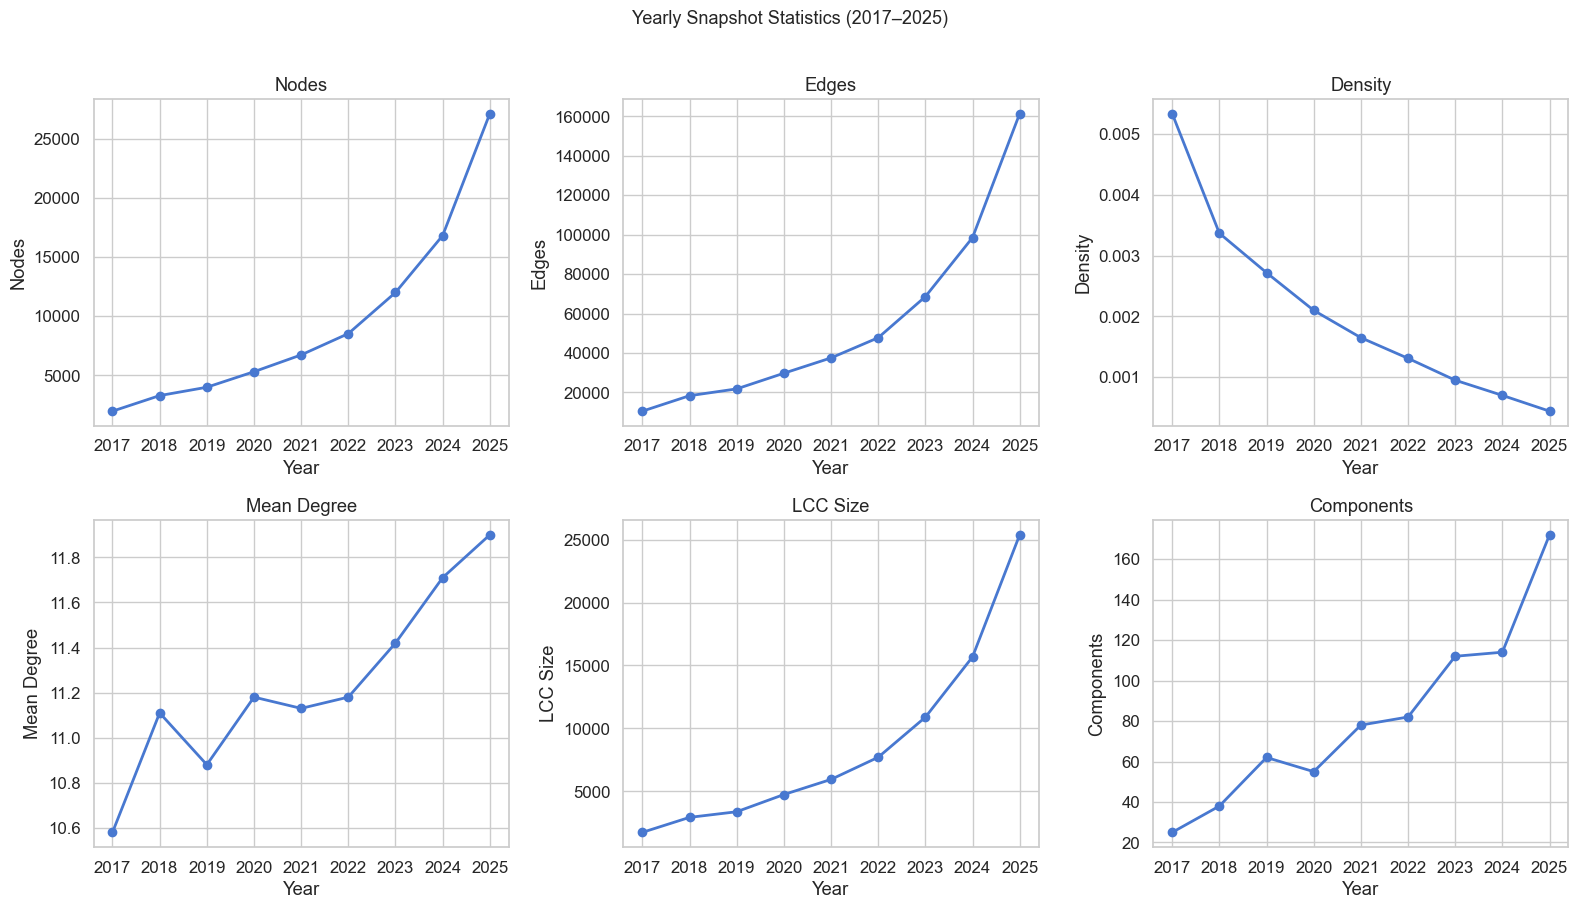

,n_papers,n_nodes,n_edges,density,mean_degree,max_degree,n_components,lcc_size
year,,,,,,,,
2017,245,1981,10480,0.00534,10.58,210,25,1743
2018,425,3298,18324,0.00337,11.11,358,38,2934
2019,502,4003,21780,0.00272,10.88,284,62,3381
2020,687,5316,29716,0.00210,11.18,473,55,4747
2021,859,6736,37494,0.00165,11.13,390,78,5949
2022,1094,8536,47721,0.00131,11.18,443,82,7707
2023,1573,12011,68556,0.00095,11.42,462,112,10889
2024,2261,16821,98496,0.00070,11.71,1700,114,15679
2025,3703,27126,161375,0.00044,11.90,3890,172,25376


In [12]:
rows_yr = []
for yr in years:
    G = nx_yearly[yr]
    degs = [d for _, d in G.degree()]
    rows_yr.append({
        'year': yr,
        'n_papers': yearly_graphs[yr]['n_docs'],
        'n_nodes': G.number_of_nodes(),
        'n_edges': G.number_of_edges(),
        'density': round(nx.density(G), 5),
        'mean_degree': round(np.mean(degs), 2),
        'max_degree': max(degs),
        'n_components': nx.number_connected_components(G),
        'lcc_size': len(max(nx.connected_components(G), key=len)),
    })

stats_yr_df = pd.DataFrame(rows_yr).set_index('year')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
metrics_yr = [
    ('n_nodes',      'Nodes'),
    ('n_edges',      'Edges'),
    ('density',      'Density'),
    ('mean_degree',  'Mean Degree'),
    ('lcc_size',     'LCC Size'),
    ('n_components', 'Components'),
]
for ax, (col, label) in zip(axes, metrics_yr):
    ax.plot(stats_yr_df.index, stats_yr_df[col], marker='o', linewidth=2, markersize=6)
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.suptitle('Yearly Snapshot Statistics (2017–2025)', fontsize=13, y=1.01)
plt.tight_layout()
savefig('09_yearly_statistics')
plt.show()

display(stats_yr_df)
